<a href="https://colab.research.google.com/github/Gratitude01-ndam/Exam1/blob/main/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


/tmp/ipykernel_2259/268101883.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_2259/268101883.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

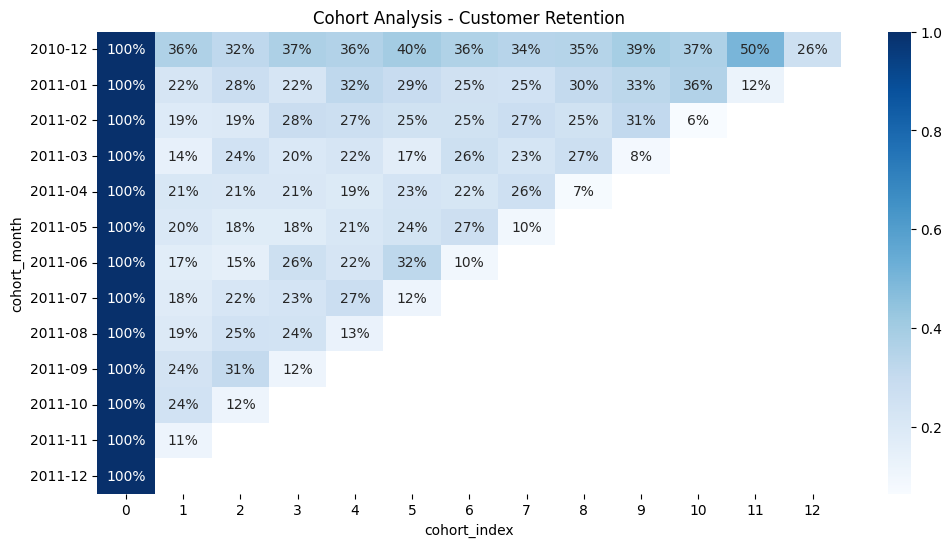

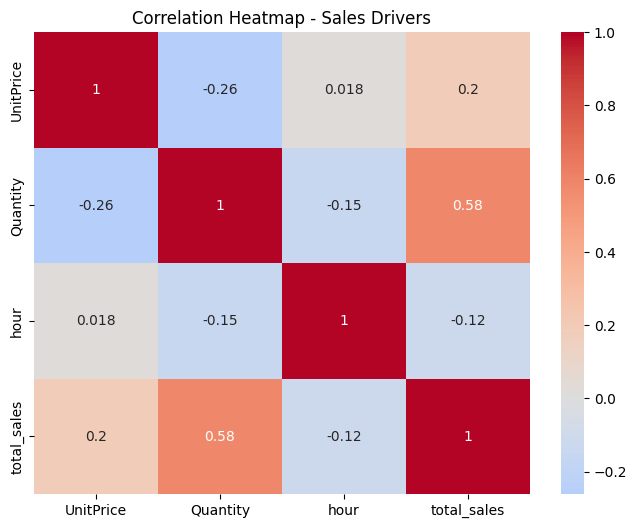

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Load and Clean the Dataset
# -------------------------------
# Example: replace 'data.csv' with your dataset file
df = pd.read_excel("/content/Online Retail.xlsx")
display(df.head())

# Handle nulls: fill numeric with median, categorical with mode
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fix data types (example: convert date column to datetime)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Remove unrealistic outliers (e.g., negative prices or quantities, extremely high values)
df = df[(df['UnitPrice'] > 0) & (df['Quantity'] > 0)]
df = df[(df['UnitPrice'] < df['UnitPrice'].quantile(0.99))]  # remove top 1% extreme outliers
df = df[(df['Quantity'] < df['Quantity'].quantile(0.99))]

# -------------------------------
# 2. Cohort Analysis (Retention)
# -------------------------------
# Define cohort by first purchase month
df['order_month'] = df['InvoiceDate'].dt.to_period('M')
df['cohort_month'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# Calculate cohort index (months since first purchase)
df['cohort_index'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

# Count unique customers per cohort per index
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['CustomerID'].nunique().reset_index()

# Pivot for retention matrix
cohort_counts = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='CustomerID')
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Plot retention heatmap
plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Analysis - Customer Retention")
plt.show()

# -------------------------------
# 3. Correlation Heatmap
# -------------------------------
# Create total sales feature
df['total_sales'] = df['UnitPrice'] * df['Quantity']

# Extract hour of day
df['hour'] = df['InvoiceDate'].dt.hour

# Select relevant features
corr_features = df[['UnitPrice', 'Quantity', 'hour', 'total_sales']]

# Compute correlation
corr_matrix = corr_features.corr()

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Sales Drivers")
plt.show()